In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import astroML.stats
import random
import math
import sklearn.mixture as mix

In [2]:
start = 0 #clody day
pcc = 0.5 #cloudy|cloudy
psc = 0.5 #sunny|cloudy
pss = 0.9 #sunny|sunny
pcs = 0.1 #cloudy|sunny

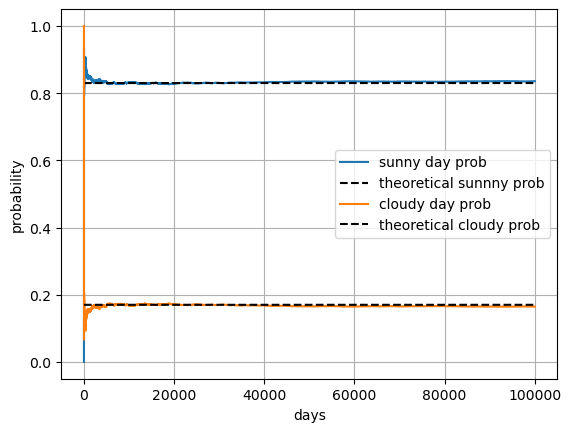

In [3]:
N = 100000
tod = start
s = 0 #count on sunny days
c = 0 #count on cloudy days
sunny_arr = []
cloudy_arr = []

for i in range(N):
    if tod == 0:
        tom = np.random.uniform(0,1,1)
        if tom < pcc: tod = 0
        if tom > pcc: tod = 1
        c = c+1
    else:
        tom = np.random.uniform(0,1,1)
        if tom < pcs: tod = 0
        if tom > pcs: tod = 1
        s = s+1
    sunny_arr.append(s/(i+1))
    cloudy_arr.append(c/(i+1))

plt.plot(np.linspace(0,N,N),sunny_arr,label='sunny day prob')
plt.plot(np.linspace(0,N,N), 0.83*np.ones(len(np.linspace(0,N,N))), '--', c='black', label='theoretical sunnny prob')
plt.plot(np.linspace(0,N,N),cloudy_arr,label='cloudy day prob')
plt.plot(np.linspace(0,N,N), 0.17*np.ones(len(np.linspace(0,N,N))), '--', c='black', label='theoretical cloudy prob')
plt.xlabel('days')
plt.ylabel('probability')
plt.legend()
plt.grid()

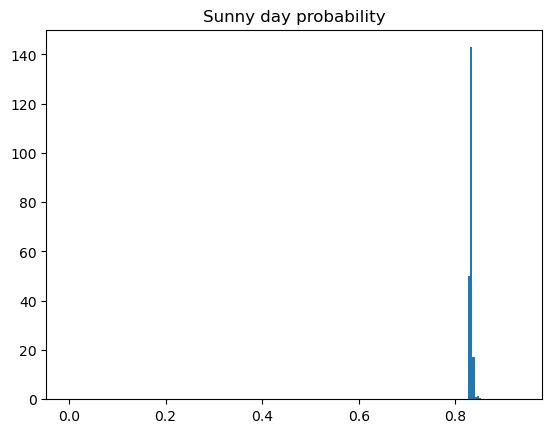

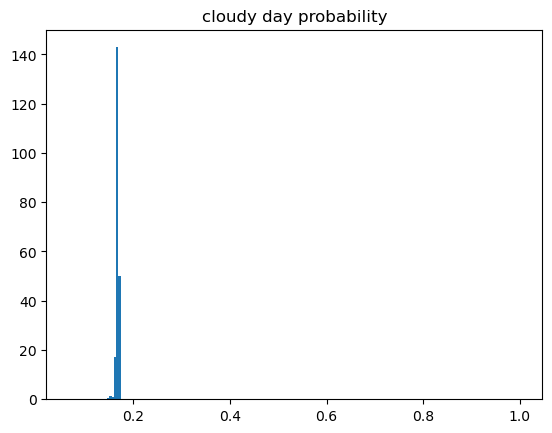

In [4]:
sunny_arr = np.array(sunny_arr)
cloudy_arr = np.array(cloudy_arr)

plt.hist(sunny_arr, bins=200, density=True)
plt.title('Sunny day probability')
plt.show()

a,b,c=plt.hist(cloudy_arr, bins=200, density=True)
plt.title('cloudy day probability')
plt.show()

In [5]:
print(np.median(sunny_arr), '+-', astroML.stats.sigmaG(sunny_arr))
print(np.median(cloudy_arr), '+-', astroML.stats.sigmaG(cloudy_arr))

0.8340826804630592 +- 0.002930438462949548
0.16591731953694078 +- 0.0029304384629494865


## Burnings

In [6]:
s_cut = sunny_arr[2000:]
c_cut = cloudy_arr[2000:]

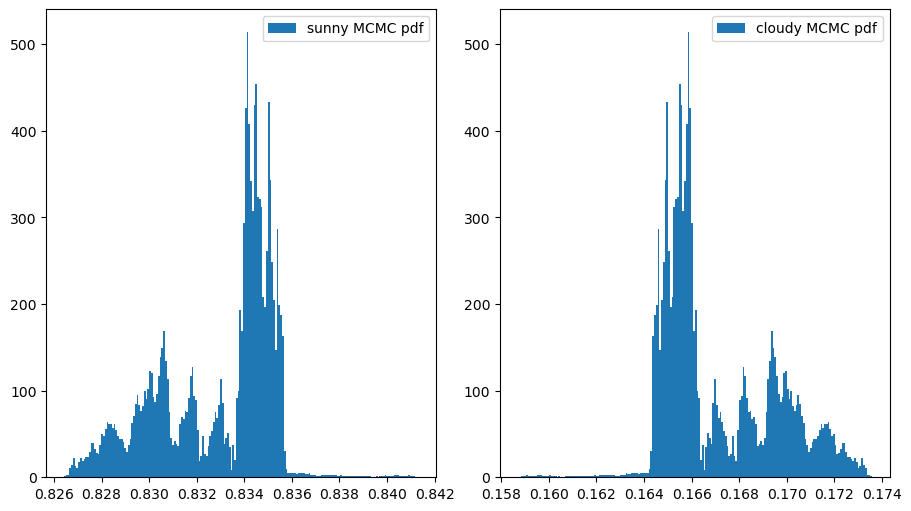

0.834060962230487 +- 0.0029262723725515254
0.16593903776951302 +- 0.0029262723725515874


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(9, 5), constrained_layout=True)
ax[0].hist(s_cut, bins=200, density=True, label='sunny MCMC pdf')
ax[1].hist(c_cut, bins=200, density=True, label='cloudy MCMC pdf')
ax[0].legend()
ax[1].legend()
plt.show()
print(np.median(s_cut), '+-', astroML.stats.sigmaG(s_cut))
print(np.median(c_cut), '+-', astroML.stats.sigmaG(c_cut))

In [8]:
s_cut = sunny_arr[20000:]
c_cut = cloudy_arr[20000:]

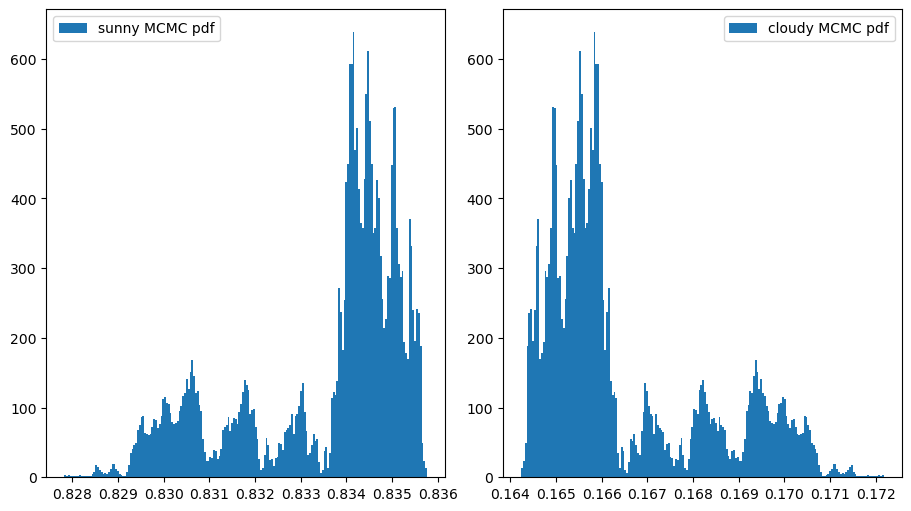

0.8342098945200771 +- 0.0017975916136718994
0.16579010547992293 +- 0.0017975916136718582


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(9, 5), constrained_layout=True)
ax[0].hist(s_cut, bins=200, density=True, label='sunny MCMC pdf')
ax[1].hist(c_cut, bins=200, density=True, label='cloudy MCMC pdf')
ax[0].legend()
ax[1].legend()
plt.show()
print(np.median(s_cut), '+-', astroML.stats.sigmaG(s_cut))
print(np.median(c_cut), '+-', astroML.stats.sigmaG(c_cut))

# Do it many times

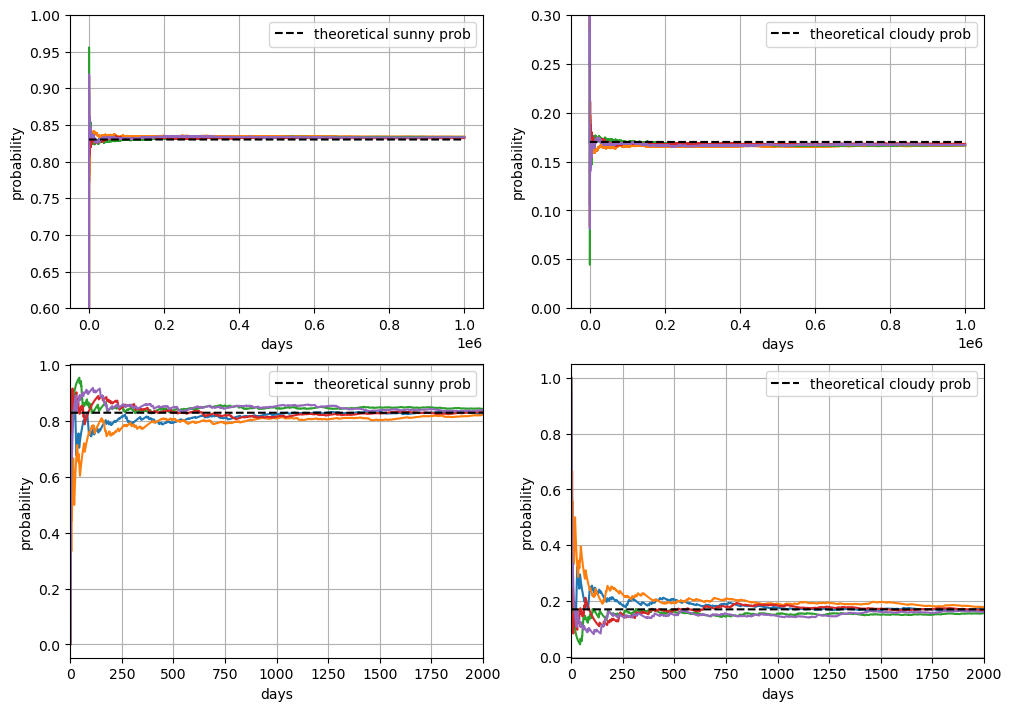

In [11]:
N = 1000000
fig, ax = plt.subplots(2,2, figsize=(10, 7), constrained_layout=True)

for j in  range(5):
    tod = start
    s = 0
    c = 0 
    sunny_arr = []
    cloudy_arr = []
    for i in range(N):
        if tod == 0:
            tom = np.random.uniform(0,1,1)
            if tom < pcc: tod = 0
            if tom > pcc: tod = 1
            c = c+1
        else:
            tom = np.random.uniform(0,1,1)
            if tom < pcs: tod = 0
            if tom > pcs: tod = 1
            s = s+1
        sunny_arr.append(s/(i+1))
        cloudy_arr.append(c/(i+1))
    
    [ax[a,0].plot(np.linspace(0,N,N),sunny_arr) for a in range(2)]
    [ax[b,1].plot(np.linspace(0,N,N),cloudy_arr) for b in range(2)]

[ax[a,0].plot(np.linspace(0,N,N), 0.83*np.ones(len(np.linspace(0,N,N))), '--', c='black', label='theoretical sunny prob') for a in range(2)]
[ax[b,1].plot(np.linspace(0,N,N), 0.17*np.ones(len(np.linspace(0,N,N))), '--', c='black', label='theoretical cloudy prob') for b in range(2)]
#[ax[a,0].set_ylim(0.6, 1.)  for a in range(2)]
#[ax[b,1].set_ylim(0., 0.3)  for b in range(2)]
ax[0,0].set_ylim(0.6, 1.)
ax[0,1].set_ylim(0., 0.3)
ax[1,0].set_xlim(0., 2000) #burn-in zoom
ax[1,1].set_xlim(0., 2000) #bur-in zoom
[[ax[j,i].set_xlabel('days') for i in range(2)] for j in range(2)]
[[ax[j,i].set_ylabel('probability') for i in range(2)] for j in range(2)]
[[ax[j,i].legend() for i in range(2)] for j in range(2)]
[[ax[j,i].grid() for i in range(2)] for j in range(2)]
plt.show()